Використай цей шаблон в роботі з датасетом. Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань. Обмежся функціями з наведених бібліотек.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Завантаж датасет з бібліотеки seaborn:

In [2]:
df = sns.load_dataset('titanic')
display(df.head()) 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


2. Переглянь перші рядки датасету. Зроби висновок, чи коректно він завантажився.

In [3]:
df.to_csv("titanic_clean.csv", index=False)


*Датасет завантажився коректно.*

3. Перевір типи стовпців. Які з них потребують перетворення?

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


***sex (object): можна перетворити на категоріальний тип (category), оскільки має обмежену кількість унікальних значень ('male', 'female').
embarked (object): також можна перетворити на категоріальний тип (category), оскільки містить кілька унікальних значень портів посадки ('S', 'C', 'Q').
who (object): аналогічно, можна перетворити на категоріальний тип (category) ('man', 'woman', 'child').
alive (object): цей стовпець, що містить 'yes' або 'no', ідеально підходить для перетворення на булевий тип (bool),
де 'yes' може бути True, а 'no' — False.***

4. Перевір статистику по УСІМ стовпцям датасету.

In [5]:
display(df.describe(include='all'))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


5. Спробуй оцінити кількість дублікатів. Виміряй число рядків, позбудься дублікатів, оціни нову кількість рядків. Різницю виведи на екран, це і буде кількість рядків.

In [6]:
original_rows = df.shape[0]
df.drop_duplicates(inplace=True)   #видаляємо дублікати прямо в df 
duplicate_rows = original_rows - df.shape[0]
print(f"Кількість рядків в оригіналі: {original_rows}")
print(f"Кількість рядків після видалення дублікатів: {df.shape[0]}")
print(f"Кількість знайдених та видалених дублікатів: {duplicate_rows}")

Кількість рядків в оригіналі: 891
Кількість рядків після видалення дублікатів: 784
Кількість знайдених та видалених дублікатів: 107


6. Необхідно створити єдиний стовпчик, що вказує кількість родичів для кожного пасажира на борту, замість:
Кількість братів/сестер або чоловіків/дружин на борту
Кількість батьків або дітей на борту
Булева ознака: True, якщо пасажир подорожував один (без родичів на борту)
після створення нового стовпчика, дропни попередні. Вони вже не потрібні.

In [7]:
df['family_members'] = df['sibsp'] + df['parch']
df.drop(columns=['sibsp', 'parch', 'alone'], inplace=True)
display(df.head())

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,family_members
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,1
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,1
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,0
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,1
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,0


7. Перевір частоту випадків за значеннями в  новому стовпчику (кількість родичів) використовуючи візуалізацію:

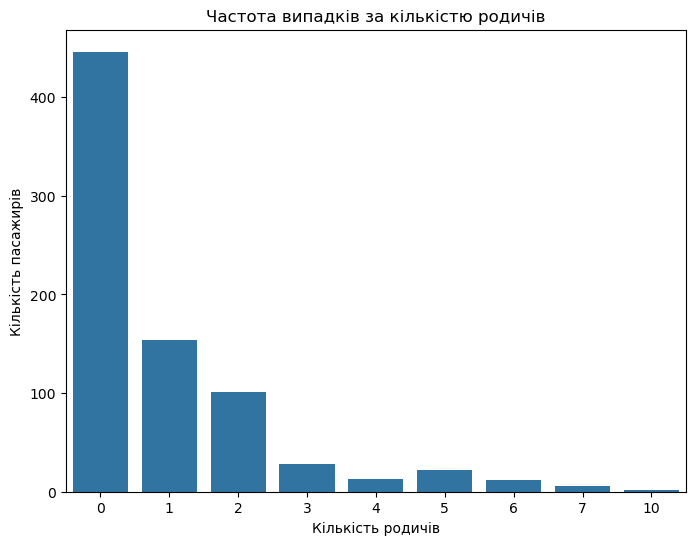

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='family_members')  #будуємо стовпчикову діаграму
plt.title('Частота випадків за кількістю родичів')
plt.xlabel('Кількість родичів')
plt.ylabel('Кількість пасажирів')
plt.show()

8. Використовуючи лямбда функцію заміни кількість родичів, що перевищує число 5(п'ять) на значення "above 5"(понад п'ять):

In [9]:
df['family_members'] = df['family_members'].apply(lambda x: 'above 5' if x > 5 else x)
display(df.head())

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,family_members
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,1
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,1
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,0
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,1
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,0


9. Необхідно вивести на екран статистику по модифікованому стовпцю, віднісши нову категорію в кінець( для цього слід перетворити стовпець в категорійний):

In [10]:
unique_values = df['family_members'].unique()
ordered_categories = sorted([x for x in unique_values if x != 'above 5'])
if 'above 5' in unique_values:
    ordered_categories.append('above 5')

df['family_members'] = pd.Categorical(df['family_members'], categories=ordered_categories, ordered=True)

display(df['family_members'].value_counts().sort_index())

family_members
0          446
1          154
2          101
3           28
4           13
5           22
above 5     20
Name: count, dtype: int64

10. Заповни відсутні значення віку медіаною.

In [11]:
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
display(df.head())

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,family_members
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,1
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,1
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,0
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,1
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,0


11. Створи новий стовпець, де вік представлено категорією, замість числа (наприклад: до 14 років, 14-34 роки, 35-59 років, 60 і більше років). Виконай задачу з використанням користувацької функції. Осіб з невідомим віком познач відповідно.

In [12]:
def categorize_age(age):
    if age < 14:
        return 'до 14 років'
    elif 14 <= age <= 34:
        return '14-34 роки'
    elif 35 <= age <= 59:
        return '35-59 років'
    elif age >= 60:
        return '60 і більше років'
    else:
        return 'Невідомий вік' 

df['age_category'] = df['age'].apply(categorize_age)
display(df.head())
display(df['age_category'].value_counts())

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,family_members,age_category
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,1,14-34 роки
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,1,35-59 років
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,0,14-34 роки
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,1,35-59 років
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,0,35-59 років


age_category
14-34 роки           482
35-59 років          205
до 14 років           70
60 і більше років     26
Невідомий вік          1
Name: count, dtype: int64

12. Перевір, в якій віковій категорії була найвища смертність. Для цього рекомендується перетворити стовпець 'alive' в булевий тип. Потім підрахувати загальну кількість пасажирів та кількість тих, хто не вижив. Потім обчисли відносний показниках для кожної категорії.

In [13]:
df['alive_bool'] = df['alive'].apply(lambda x: False if x == 'no' else True) #перетворюємо в булевий тип

mortality_by_age_category = df.groupby('age_category')['alive_bool'].agg(
    total_passengers='count',
    non_survivors=lambda x: (x == False).sum()
).reset_index()

mortality_by_age_category['mortality_rate'] = (
    round(mortality_by_age_category['non_survivors'] / mortality_by_age_category['total_passengers'] *100,2)
)

display(mortality_by_age_category.sort_values(by='mortality_rate', ascending=False))

highest_mortality_category = mortality_by_age_category.loc[mortality_by_age_category['mortality_rate'].idxmax()]
print(f"\nВікова категорія з найвищою смертністю: {highest_mortality_category['age_category']} "
      f"з показником смертності {highest_mortality_category['mortality_rate']:.2f}")



,age_category,total_passengers,non_survivors,mortality_rate
3,Невідомий вік,1,1,100.00
2,60 і більше років,26,19,73.08
0,14-34 роки,482,293,60.79
1,35-59 років,205,119,58.05
4,до 14 років,70,29,41.43



Вікова категорія з найвищою смертністю: Невідомий вік з показником смертності 100.00


***Вікова категорія з найвищою смертністю: Невідомий вік з показником смертності 100%, але цією категорією можна нехтувати, оскільки там всього 1 пасажир.
Тож якщо не враховувати пасажира з невідомим віком, найвища смертність в категорії "60 і більше років" - 73%***

13. Відтвори cтатистику  смертності у вигляді кругової діаграми з розбивкою по віковим групам. Ти помітив, що відсотки відрізняються? Поясни чому.

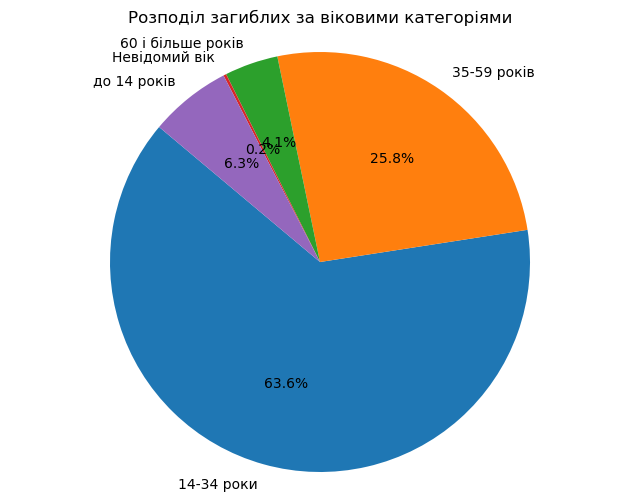

,age_category,mortality_rate,percentage_of_total_non_survivors
0,14-34 роки,60.79,63.56
1,35-59 років,58.05,25.81
2,60 і більше років,73.08,4.12
3,Невідомий вік,100.00,0.22
4,до 14 років,41.43,6.29


In [14]:
total_non_survivors = mortality_by_age_category['non_survivors'].sum()
mortality_by_age_category['percentage_of_total_non_survivors'] = \
    round((mortality_by_age_category['non_survivors'] / total_non_survivors) * 100,2)

plt.figure(figsize=(8, 6))
plt.pie(mortality_by_age_category['percentage_of_total_non_survivors'], 
        labels=mortality_by_age_category['age_category'], 
        autopct='%1.1f%%', startangle=140)
plt.title('Розподіл загиблих за віковими категоріями')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

display(mortality_by_age_category[['age_category', 'mortality_rate', 'percentage_of_total_non_survivors']])


***Відмінності у відсотках: у попередньому кроці ми розраховували показник смертності для кожної вікової категорії, 
тобто частку загиблих в межах цієї конкретної категорії.
Кругова діаграма показує частку кожної вікової категорії у загальній кількості загиблих.
Ці відсотки можуть відрізнятися, оскільки вони вимірюють різні речі: один - внутрішній показник групи,
інший - внесок групи до загальної кількості смертей.***

14. *Бонусне завдання*

Підготуй розгорнуту статистику смертності по категорії віку, класу квитка, рівню каюти та кількості родичів. Які фактори, на твою думку, найбільше пов'язані з рівнем смерності? (наприклад: найбільша смертність у відсотковому значенні спостерігається серед вікової групи ... класу квитка.... при наявності ... родичів та для рівня каюти.... Фактор ... має найвищий вплив на смертність)

#### **Створення функції, яка дає статистику смертності за наданою категорією**

In [15]:
# Функція аналізує смертність за заданою категорією.
# Параметри: вхідний датафрейм, який містить колонку 'alive_bool';
# категоря за якою відбувається групування та статистичний аналіз.
# Повертає: highest_category (Series): Рядок з категорією, яка має найвищу смертність

def mortality_analysis(group_col):
    # Групування та агрегація
    mortality_stats = df.groupby(group_col, observed=True)['alive_bool'].agg(
        total_passengers='count',
        non_survivors=lambda x: (x == False).sum()
    ).reset_index()
    
    # Обчислення рівня смертності (%)
    mortality_stats['mortality_rate'] = (
        round(mortality_stats['non_survivors'] / mortality_stats['total_passengers'] * 100, 2)
    )
    
    # Показати таблицю
    display(mortality_stats.sort_values(by='mortality_rate', ascending=False))

    # Будуємо графік
    if group_col != 'family_members':
        graphing(group_col, mortality_stats)
    
    # Категорія з найвищою смертністю
    highest_category = mortality_stats.loc[mortality_stats['mortality_rate'].idxmax()]
    print(f"\nКатегорія '{highest_category[group_col]}' "
          f"має найвищу смертність: {highest_category['mortality_rate']:.2f}%")
    
    return highest_category


In [16]:
# Фукція будує стовпчикову діаграму смертності за даною категорією.

def graphing(group_col, mortality_stats):
    plt.figure(figsize=(5, 4))
    plt.bar(mortality_stats[group_col], mortality_stats['mortality_rate'], 
            color='salmon', edgecolor='black')
    plt.title(f'Рівень смертності за категорією: {group_col}')
    plt.xlabel(group_col)
    plt.ylabel('Смертність (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### **Статистика смертності по категорії віку**

,age_category,total_passengers,non_survivors,mortality_rate
3,Невідомий вік,1,1,100.00
2,60 і більше років,26,19,73.08
0,14-34 роки,482,293,60.79
1,35-59 років,205,119,58.05
4,до 14 років,70,29,41.43


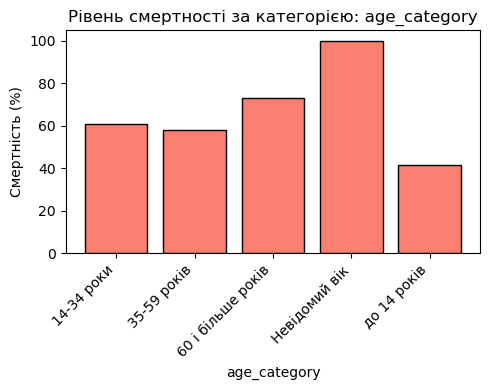


Категорія 'Невідомий вік' має найвищу смертність: 100.00%


age_category        Невідомий вік
total_passengers                1
non_survivors                   1
mortality_rate              100.0
Name: 3, dtype: object

In [17]:
mortality_analysis('age_category')

### **Статистика смертності за класом квитка**

,pclass,total_passengers,non_survivors,mortality_rate
2,3,405,301,74.32
1,2,165,81,49.09
0,1,214,79,36.92


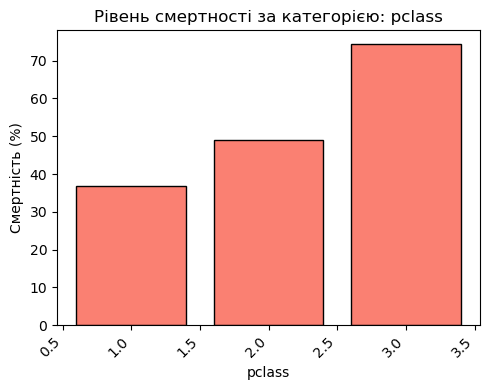


Категорія '3.0' має найвищу смертність: 74.32%


pclass                3.00
total_passengers    405.00
non_survivors       301.00
mortality_rate       74.32
Name: 2, dtype: float64

In [18]:
mortality_analysis('pclass')

### **Статистика смертності за рівнем каюти**

,deck,total_passengers,non_survivors,mortality_rate
0,A,15,8,53.33
6,G,4,2,50.00
2,C,59,24,40.68
5,F,13,5,38.46
1,B,46,12,26.09
4,E,32,8,25.00
3,D,33,8,24.24


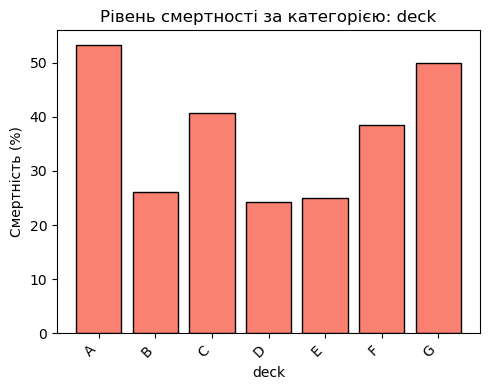


Категорія 'A' має найвищу смертність: 53.33%


deck                    A
total_passengers       15
non_survivors           8
mortality_rate      53.33
Name: 0, dtype: object

In [19]:
mortality_analysis('deck')

### **Статистика смертності за кількістю родичів**

In [20]:
mortality_analysis('family_members')

,family_members,total_passengers,non_survivors,mortality_rate
5,5,22,19,86.36
6,above 5,20,16,80.00
4,4,13,10,76.92
0,0,446,296,66.37
1,1,154,69,44.81
2,2,101,43,42.57
3,3,28,8,28.57



Категорія '5' має найвищу смертність: 86.36%


family_members          5
total_passengers       22
non_survivors          19
mortality_rate      86.36
Name: 5, dtype: object

### **Статистика смертності за статтю**

,sex,total_passengers,non_survivors,mortality_rate
1,male,491,385,78.41
0,female,293,76,25.94


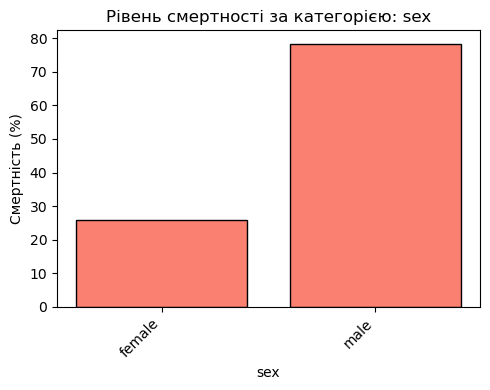


Категорія 'male' має найвищу смертність: 78.41%


sex                  male
total_passengers      491
non_survivors         385
mortality_rate      78.41
Name: 1, dtype: object

In [21]:
mortality_analysis('sex')

**Найбільша смертність у відсотковому значенні спостерігається серед вікової групи "60 і більше років", чоловічої статі, класу квитка 3 при наявності 5 родичів та для рівня каюти А.                                                                                                                           
Аналіз показав, що найвищі відсотки смертності можуть спостерігатися у невеликих групах (наприклад, пасажири з великою кількістю родичів або ті, хто перебував на нижніх палубах). Проте такі групи не визначають загальну картину, бо охоплюють мало людей. Найсильніший вплив на рівень смертності мають стать та клас квитка: чоловіки загалом мали смертність понад 78%, тоді як жінки близько 26%; пасажири 3-го класу мали смертність близько 74%, тоді як у 1-му класі — лише 37%. Саме ці фактори охоплюють найбільші групи пасажирів і найчіткіше розділяють шанси на виживання, тому їх можна вважати ключовими факторами смертності.**
